In [72]:
%pip install seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
import seaborn as sns
import statsmodels.api as sm

file_path = "movies.csv"
df = pd.read_csv(file_path, encoding="latin1")

Note: you may need to restart the kernel to use updated packages.


## **1. Exploración rápida del dataset**

In [73]:
print(f"Dimensiones del dataset: {df.shape[0]} filas, {df.shape[1]} columnas")

Dimensiones del dataset: 10000 filas, 27 columnas


In [74]:
print("\nInformación general del dataset:")
print(df.info())


Información general del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         10000 non-null  int64  
 1   budget                     10000 non-null  int64  
 2   genres                     9947 non-null   object 
 3   homePage                   4193 non-null   object 
 4   productionCompany          9543 non-null   object 
 5   productionCompanyCountry   8720 non-null   object 
 6   productionCountry          9767 non-null   object 
 7   revenue                    10000 non-null  float64
 8   runtime                    10000 non-null  int64  
 9   video                      9514 non-null   object 
 10  director                   9926 non-null   object 
 11  actors                     9920 non-null   object 
 12  actorsPopularity           9913 non-null   object 
 13  actorsCharact

In [75]:
print("\nEstadísticas descriptivas de las variables numéricas:")
print(df.describe())


Estadísticas descriptivas de las variables numéricas:
                  id        budget       revenue       runtime    popularity  \
count   10000.000000  1.000000e+04  1.000000e+04  10000.000000  10000.000000   
mean   249876.829300  1.855163e+07  5.673793e+07    100.268100     51.393907   
std    257380.109004  3.662669e+07  1.495854e+08     27.777829    216.729552   
min         5.000000  0.000000e+00  0.000000e+00      0.000000      4.258000   
25%     12286.500000  0.000000e+00  0.000000e+00     90.000000     14.577750   
50%    152558.000000  5.000000e+05  1.631245e+05    100.000000     21.905500   
75%    452021.750000  2.000000e+07  4.479661e+07    113.000000     40.654000   
max    922260.000000  3.800000e+08  2.847246e+09    750.000000  11474.647000   

            voteAvg     voteCount  genresAmount  productionCoAmount  \
count  10000.000000  10000.000000  10000.000000        10000.000000   
mean       6.483490   1342.381800      2.596500            3.171400   
std        

In [76]:
# Calcular el porcentaje de valores nulos
missing_percentage = (df.isnull().sum() / len(df)) * 100

# Filtrar solo las columnas con valores nulos
missing_percentage = missing_percentage[missing_percentage > 0]

print("\nPorcentaje de valores nulos en el dataset:")
print(missing_percentage)


Porcentaje de valores nulos en el dataset:
genres                       0.53
homePage                    58.07
productionCompany            4.57
productionCompanyCountry    12.80
productionCountry            2.33
video                        4.86
director                     0.74
actors                       0.80
actorsPopularity             0.87
actorsCharacter              0.47
dtype: float64


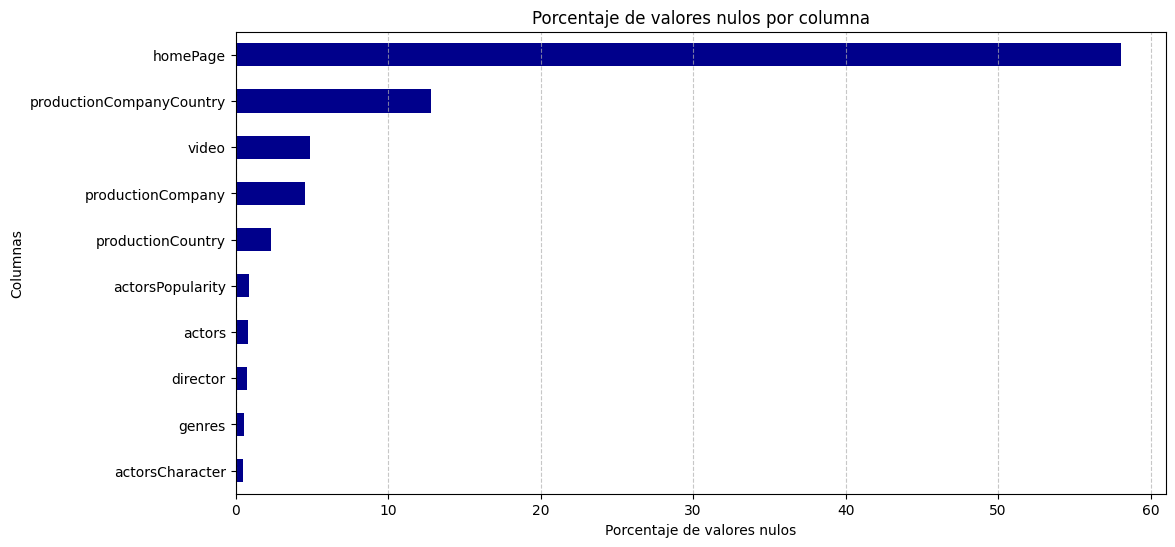

In [77]:
plt.figure(figsize=(12, 6))
missing_percentage.sort_values().plot(kind='barh', color='darkblue')

plt.xlabel("Porcentaje de valores nulos")
plt.ylabel("Columnas")
plt.title("Porcentaje de valores nulos por columna")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [78]:
# calcular el promedio de la popularidad de actores por película

def calcular_promedio_popularidad(val):
    if isinstance(val, str):  
        valores = [float(i) for i in val.strip('|').split('|') if i.replace('.', '', 1).isdigit()]  
        return np.mean(valores) if valores else np.nan  
    return np.nan  

df['actorsPopularity'] = df['actorsPopularity'].apply(calcular_promedio_popularidad)

print(df['actorsPopularity'].head(10))  
print("Valores únicos en 'actorsPopularity':", df['actorsPopularity'].nunique())

0    11.580640
1     6.476200
2     2.135924
3     8.139208
4     3.654921
5     4.824250
6     1.434987
7     4.962828
8     2.956991
9     1.533375
Name: actorsPopularity, dtype: float64
Valores únicos en 'actorsPopularity': 9782


## **2. Clasificación de las variables del dataset**

In [79]:
df['castWomenAmount'] = pd.to_numeric(df['castWomenAmount'], errors='coerce').astype('Int64')
df['castMenAmount'] = pd.to_numeric(df['castMenAmount'], errors='coerce').astype('Int64')

qualitative_nominal = []  
qualitative_ordinal = [] 
quantitative_continuous = []  
quantitative_discrete = [] 


for column in df.columns:
    if df[column].dtype == 'object':  # Variables categóricas (texto)
        qualitative_nominal.append(column)
    elif df[column].dtype in ['int64', 'Int64', 'float64']:  # Variables numéricas
        unique_values = df[column].nunique()
        if unique_values < 10:  # Se considera ordinal si tiene pocos valores únicos
            qualitative_ordinal.append(column)
        elif df[column].dtype in ['int64', 'Int64']:  # Variables discretas (enteros)
            quantitative_discrete.append(column)
        else:  # Variables continuas (decimales)
            quantitative_continuous.append(column)


print(f"Cualitativas nominales ({len(qualitative_nominal)}): {qualitative_nominal}")
print(f"Cualitativas ordinales ({len(qualitative_ordinal)}): {qualitative_ordinal}")
print(f"Cuantitativas continuas ({len(quantitative_continuous)}): {quantitative_continuous}")
print(f"Cuantitativas discretas ({len(quantitative_discrete)}): {quantitative_discrete}")


Cualitativas nominales (13): ['genres', 'homePage', 'productionCompany', 'productionCompanyCountry', 'productionCountry', 'video', 'director', 'actors', 'actorsCharacter', 'originalTitle', 'title', 'originalLanguage', 'releaseDate']
Cualitativas ordinales (0): []
Cuantitativas continuas (4): ['revenue', 'actorsPopularity', 'popularity', 'voteAvg']
Cuantitativas discretas (10): ['id', 'budget', 'runtime', 'voteCount', 'genresAmount', 'productionCoAmount', 'productionCountriesAmount', 'actorsAmount', 'castWomenAmount', 'castMenAmount']


## **3.1 Las variables cuantitativas siguen una distribución normal?**

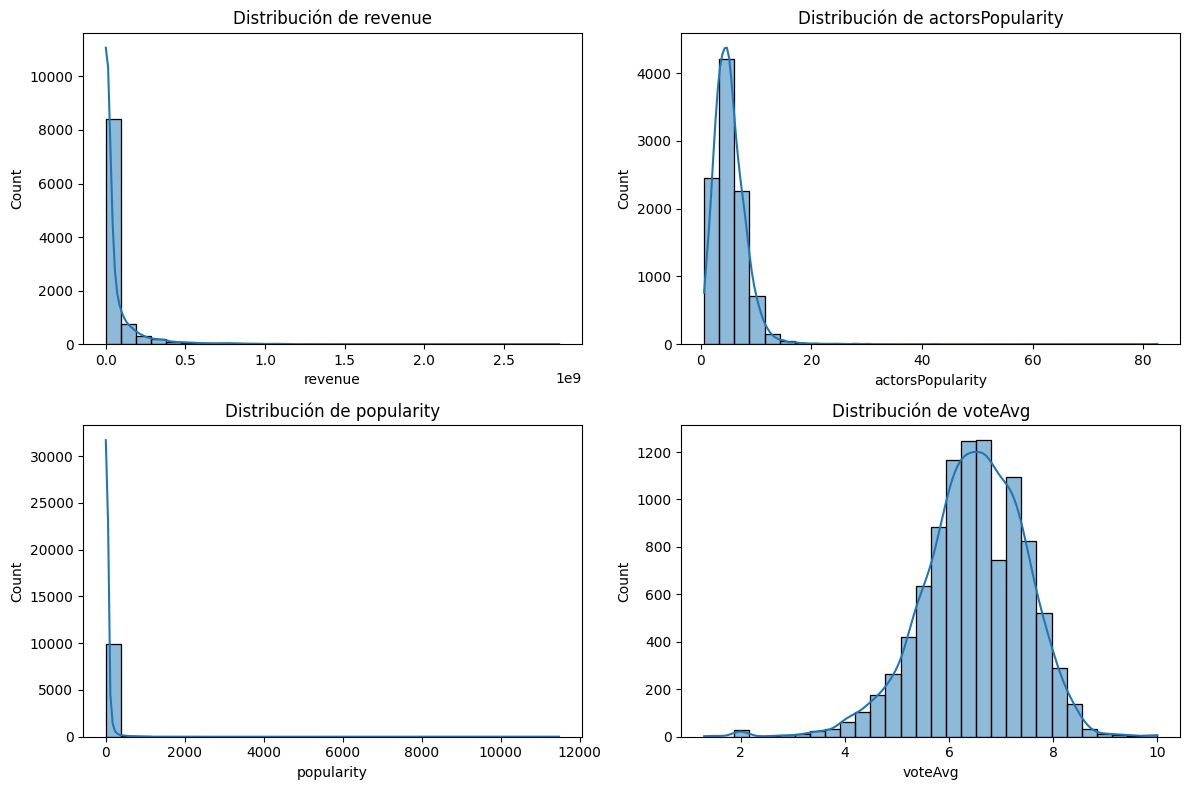

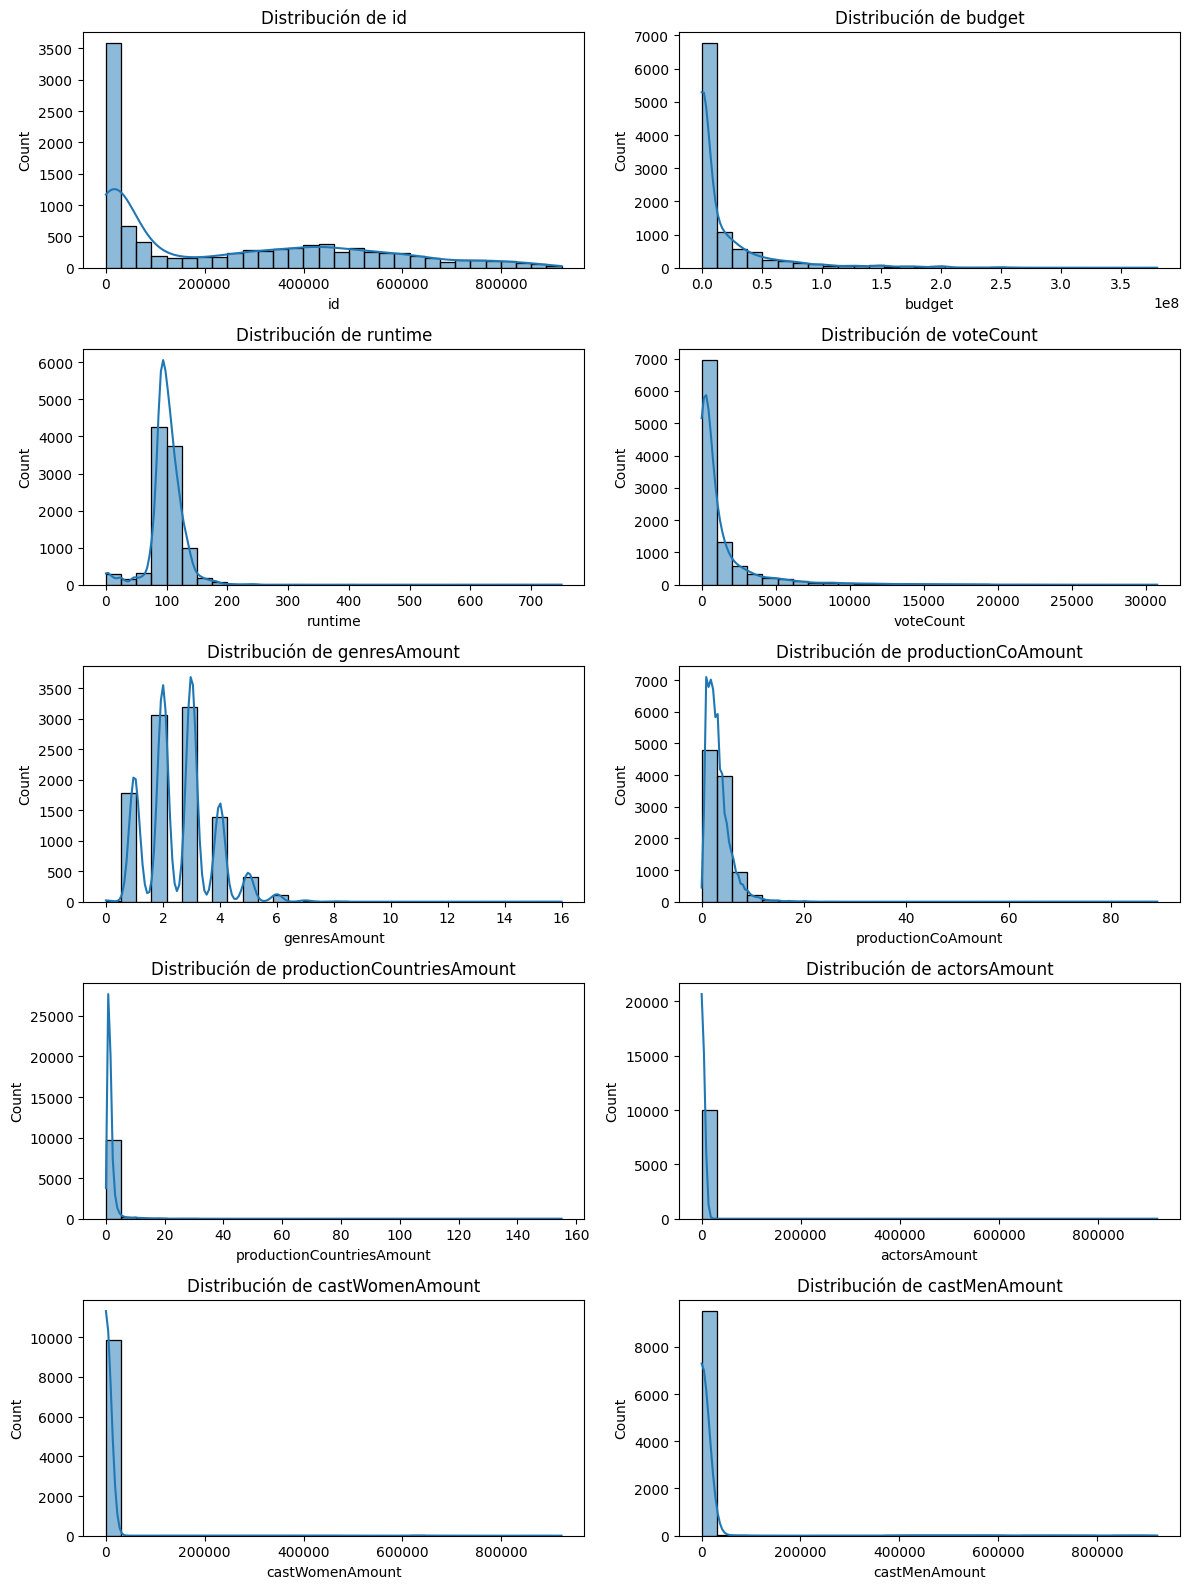

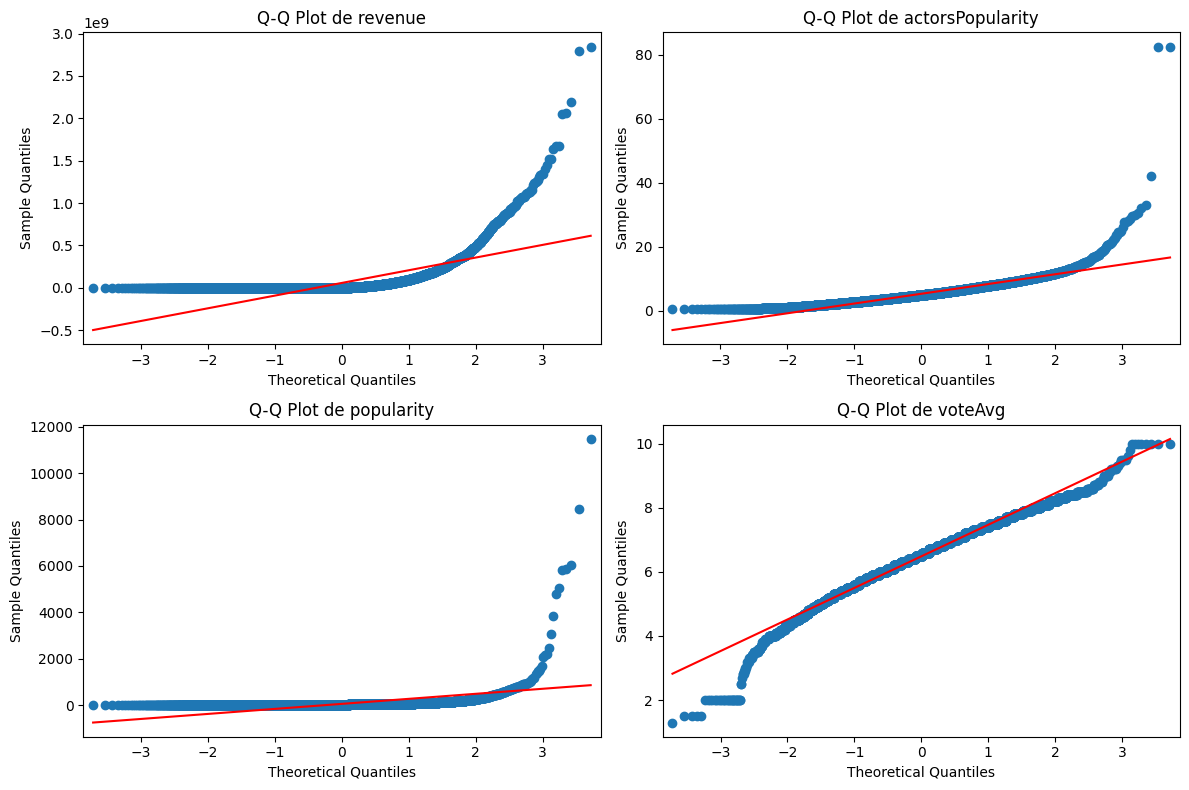

Resultados de la prueba de Kolmogorov-Smirnov para variables continuas:


,Statistic,P-Value,Normal
revenue,0.352232,0.0,False
actorsPopularity,0.074546,0.0,False
popularity,0.417335,0.0,False
voteAvg,0.04591,0.0,False



Resultados de la prueba de Kolmogorov-Smirnov para variables discretas:


,Statistic,P-Value,Normal
id,0.200786,0.0,False
budget,0.306251,0.0,False
runtime,0.14408,0.0,False
voteCount,0.300445,0.0,False
genresAmount,0.183598,0.0,False
productionCoAmount,0.200403,0.0,False
productionCountriesAmount,0.392653,0.0,False
actorsAmount,0.516689,0.0,False
castWomenAmount,0.52831,0.0,False
castMenAmount,0.52814,0.0,False


In [80]:
quantitative_continuous_vars = ['revenue', 'actorsPopularity', 'popularity', 'voteAvg']
quantitative_discrete_vars = ['id', 'budget', 'runtime', 'voteCount', 'genresAmount', 
                              'productionCoAmount', 'productionCountriesAmount', 'actorsAmount', 
                              'castWomenAmount', 'castMenAmount']

for var in quantitative_continuous_vars + quantitative_discrete_vars:
    df[var] = pd.to_numeric(df[var], errors='coerce')

# Aplicar la prueba de Kolmogorov-Smirnov para normalidad
def ks_test(variable):
    clean_data = df[variable].dropna()
    if len(clean_data) >= 3:
        stat, p_value = stats.kstest(clean_data, 'norm', args=(clean_data.mean(), clean_data.std()))
        return {'Statistic': stat, 'P-Value': p_value, 'Normal': p_value > 0.05}
    else:
        return {'Statistic': np.nan, 'P-Value': np.nan, 'Normal': np.nan}

normality_results_continuous = {var: ks_test(var) for var in quantitative_continuous_vars}
normality_results_discrete = {var: ks_test(var) for var in quantitative_discrete_vars}

normality_df_continuous = pd.DataFrame(normality_results_continuous).T
normality_df_discrete = pd.DataFrame(normality_results_discrete).T

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for i, var in enumerate(quantitative_continuous_vars):
    sns.histplot(df[var].dropna(), kde=True, bins=30, ax=axes[i])
    axes[i].set_title(f'Distribución de {var}')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(5, 2, figsize=(12, 16))
axes = axes.flatten()
for i, var in enumerate(quantitative_discrete_vars):
    sns.histplot(df[var].dropna(), kde=True, bins=30, ax=axes[i])
    axes[i].set_title(f'Distribución de {var}')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for i, var in enumerate(quantitative_continuous_vars):
    sm.qqplot(df[var].dropna(), line='s', ax=axes[i])
    axes[i].set_title(f'Q-Q Plot de {var}')
plt.tight_layout()
plt.show()


print("Resultados de la prueba de Kolmogorov-Smirnov para variables continuas:")
display(normality_df_continuous)

print("\nResultados de la prueba de Kolmogorov-Smirnov para variables discretas:")
display(normality_df_discrete)



## Prueba para verificar sesgos

In [81]:
skewness_kurtosis = df[quantitative_continuous_vars + quantitative_discrete_vars].skew().to_frame(name="Skewness")
skewness_kurtosis["Kurtosis"] = df[quantitative_continuous_vars + quantitative_discrete_vars].kurtosis()
display(skewness_kurtosis)


,Skewness,Kurtosis
revenue,5.919857,55.932018
actorsPopularity,4.783214,90.687716
popularity,30.378934,1226.192397
voteAvg,-0.5778,1.487066
id,0.681957,-0.790283
budget,3.244864,13.218236
runtime,0.97199,35.554741
voteCount,4.147104,22.782155
genresAmount,0.691445,2.107499
productionCoAmount,5.988578,140.372931


## **3.2 Tabla de frecuencias de las variables cualitativas**

In [82]:
qualitative_nominal_vars = ['genres', 'homePage', 'productionCompany', 'productionCompanyCountry', 
                            'productionCountry', 'video', 'director', 'actors', 'actorsCharacter', 
                            'originalTitle', 'title', 'originalLanguage', 'releaseDate']

def count_frequencies(column):
    all_values = df[column].dropna().astype(str).str.split('|').explode()  # Dividir y expandir
    all_values = all_values.str.strip()  # Eliminar espacios en blanco antes y después de cada valor
    all_values = all_values[all_values != ""]  # Eliminar valores vacíos resultantes
    return all_values.value_counts().reset_index().rename(columns={'index': column, column: 'Frecuencia'})


frequency_tables = {var: count_frequencies(var) for var in qualitative_nominal_vars}

for var, table in frequency_tables.items():
    print(f"\nTabla de Frecuencia para {var}:")
    display(table.head(10)) 


Tabla de Frecuencia para genres:


,Frecuencia,count
0,Drama,3789
1,Comedy,3018
2,Action,2632
3,Thriller,2565
4,Adventure,1769
5,Horror,1512
6,Animation,1460
7,Romance,1428
8,Family,1407
9,Fantasy,1284



Tabla de Frecuencia para homePage:


,Frecuencia,count
0,http://www.naruto-movie.com/,6
1,http://www.thehungergames.movie/,4
2,http://www.p3m.jp/,3
3,http://www.kungfupanda.com/,3
4,http://kizumonogatari-usa.com/,3
5,http://www.missionimpossible.com/,3
6,http://www.kungfupanda.com,3
7,http://www.transformersmovie.com/,3
8,http://initiald-movie.com/,3
9,http://wwws.warnerbros.co.jp/rurouni-kenshin/i...,3



Tabla de Frecuencia para productionCompany:


...

,Frecuencia,count
0,Pinocchio,4
1,Cinderella,4
2,Carrie,3
3,The Courier,3
4,Awake,3
5,Escape Room,3
6,Halloween,3
7,Porno,3
8,Godzilla,3
9,The Call,3



Tabla de Frecuencia para originalLanguage:


,Frecuencia,count
0,en,7772
1,ja,644
2,es,425
3,fr,271
4,ko,167
5,zh,119
6,it,100
7,de,84
8,cn,80
9,ru,67



Tabla de Frecuencia para releaseDate:


,Frecuencia,count
0,2021-10-08,15
1,2021-02-12,15
2,2021-10-01,14
3,2021-11-12,12
4,2019-11-08,11
5,2021-07-23,11
6,2020-10-02,11
7,2021-06-11,11
8,2019-05-24,11
9,2021-12-17,10


## **4. ¿Cuáles son las 10 películas que contaron con más presupuesto?**

In [83]:
top_budget_movies = df[['title', 'originalTitle', 'budget']].sort_values(by='budget', ascending=False).head(10).reset_index(drop=True)
print("Las 10 películas con mayor presupuesto:")
display(top_budget_movies)

Las 10 películas con mayor presupuesto:


,title,originalTitle,budget
0,Pirates of the Caribbean: On Stranger Tides,Pirates of the Caribbean: On Stranger Tides,380000000
1,Avengers: Age of Ultron,Avengers: Age of Ultron,365000000
2,Avengers: Endgame,Avengers: Endgame,356000000
3,Justice League,Justice League,300000000
4,Avengers: Infinity War,Avengers: Infinity War,300000000
5,Pirates of the Caribbean: At World's End,Pirates of the Caribbean: At World's End,300000000
6,Superman Returns,Superman Returns,270000000
7,The Lion King,The Lion King,260000000
8,Tangled,Tangled,260000000
9,Spider-Man 3,Spider-Man 3,258000000


## **5. ¿Cuáles son las 10 películas que más ingresos tuvieron?**

In [84]:
df['revenue'] = pd.to_numeric(df['revenue'], errors='coerce')

top_revenue_movies = df[['title', 'originalTitle', 'revenue']].sort_values(by='revenue', ascending=False).head(10).reset_index(drop=True)

print("Las 10 películas con mayores ingresos:")
display(top_revenue_movies)

Las 10 películas con mayores ingresos:


,title,originalTitle,revenue
0,Avatar,Avatar,2.847246e+09
1,Avengers: Endgame,Avengers: Endgame,2.797801e+09
2,Titanic,Titanic,2.187464e+09
3,Star Wars: The Force Awakens,Star Wars: The Force Awakens,2.068224e+09
4,Avengers: Infinity War,Avengers: Infinity War,2.046240e+09
5,Jurassic World,Jurassic World,1.671713e+09
6,The Lion King,The Lion King,1.667635e+09
7,Spider-Man: No Way Home,Spider-Man: No Way Home,1.631853e+09
8,The Avengers,The Avengers,1.518816e+09
9,Furious 7,Furious 7,1.515048e+09


## **6. ¿Cuál es la película que más votos tuvo?¿Cuál es la película que más votos tuvo?**

In [85]:
df['voteCount'] = pd.to_numeric(df['voteCount'], errors='coerce')

top_voted_movie = df[['title', 'originalTitle', 'voteCount']].sort_values(by='voteCount', ascending=False).head(1).reset_index(drop=True)

print("La película con más votos:")
display(top_voted_movie)

La película con más votos:


,title,originalTitle,voteCount
0,Inception,Inception,30788


## **7. ¿Cuál es la peor película de acuerdo a los votos de todos los usuarios?**

In [86]:
df['voteAvg'] = pd.to_numeric(df['voteAvg'], errors='coerce')

worst_movie = df[['title', 'voteAvg', 'voteCount']].sort_values(by='voteAvg', ascending=True).head(1).reset_index(drop=True)

print("La peor película según la calificación de los usuarios:")
display(worst_movie)

La peor película según la calificación de los usuarios:


,title,voteAvg,voteCount
0,DAKAICHI -I'm Being Harassed by the Sexiest Ma...,1.3,2


## **8. ¿Cuántas películas se hicieron en cada año? ¿En qué año se hicieron más películas? Haga un gráfico de barras.**

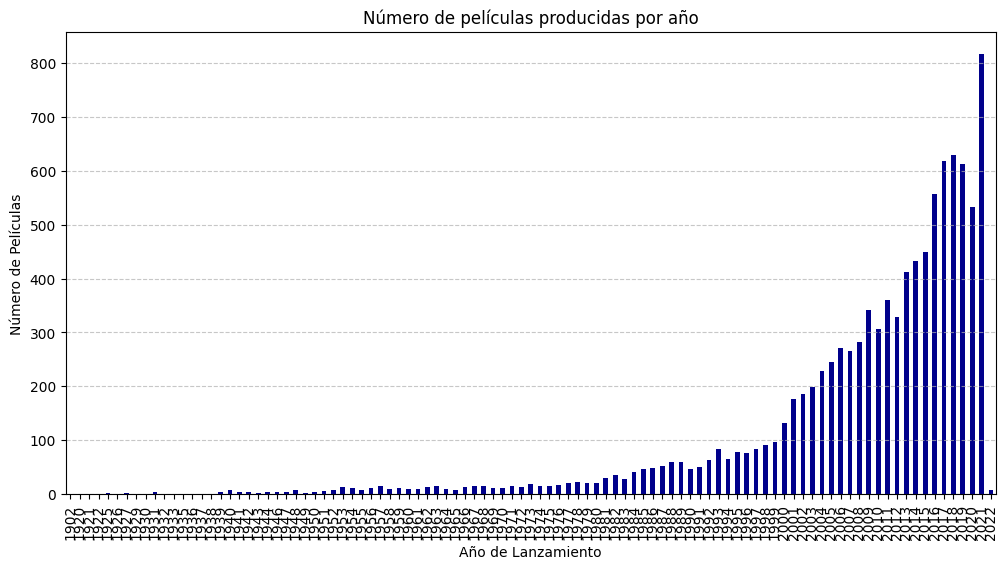

El año con más películas lanzadas fue: 2021 con 816 películas


In [87]:
df['releaseDate'] = pd.to_datetime(df['releaseDate'], errors='coerce')
df['releaseYear'] = df['releaseDate'].dt.year

movies_per_year = df['releaseYear'].value_counts().sort_index()

plt.figure(figsize=(12, 6))
movies_per_year.plot(kind='bar', color='darkblue')
plt.xlabel("Año de Lanzamiento")
plt.ylabel("Número de Películas")
plt.title("Número de películas producidas por año")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

most_movies_year = movies_per_year.idxmax()
print(f"El año con más películas lanzadas fue: {most_movies_year} con {movies_per_year.max()} películas")

## **9. ¿Cuál es el género principal de las 20 películas más recientes? ¿Cuál es el género principal que predomina en el conjunto de datos? Represéntelo usando un gráfico. ¿A qué género principal pertenecen las películas más largas**

El género principal de las 20 películas más recientes es 'Comedy' con 6 películas.


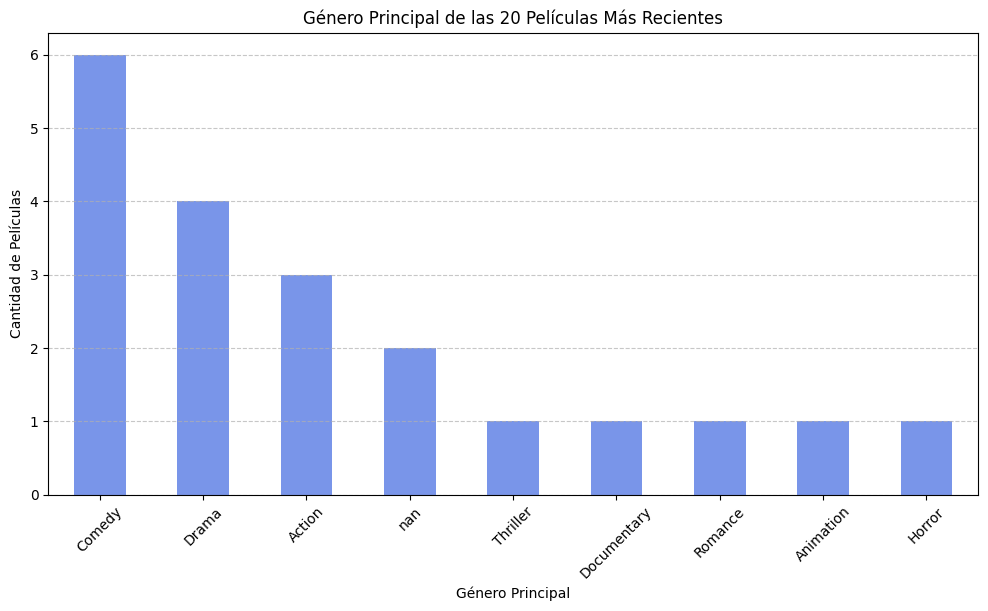

El género principal que predomina en el conjunto de datos es 'Drama' con 1803 películas.


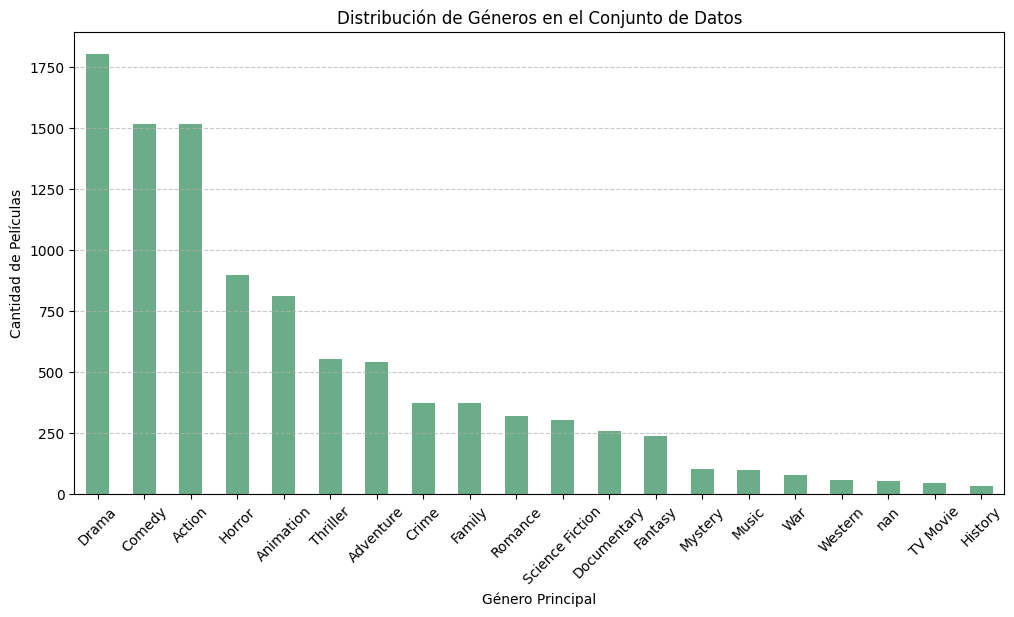

El género principal de las películas más largas es 'Drama' con 7 películas.


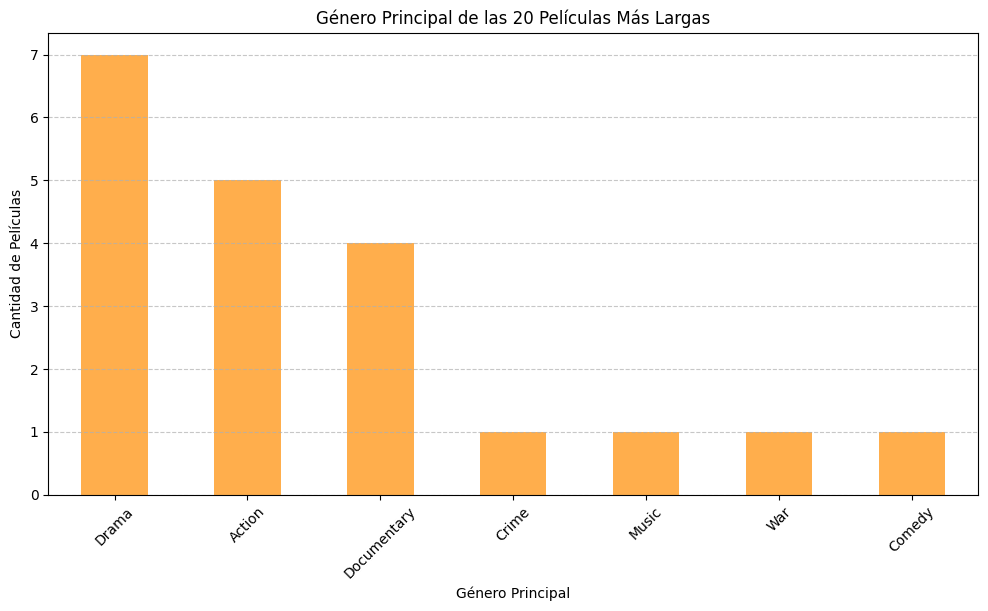

In [88]:
df['releaseDate'] = pd.to_datetime(df['releaseDate'], errors='coerce')
df['primaryGenre'] = df['genres'].astype(str).apply(lambda x: x.split('|')[0] if pd.notna(x) else 'Desconocido')

recent_movies = df.sort_values(by='releaseDate', ascending=False).head(20)
recent_genres = recent_movies['primaryGenre'].value_counts()
recent_genre_most_common = recent_genres.idxmax()
recent_genre_count = recent_genres.max()

top_genres = df['primaryGenre'].value_counts()
most_common_genre = top_genres.idxmax()
most_common_genre_count = top_genres.max()

longest_movies = df.sort_values(by='runtime', ascending=False).head(20)
longest_genres = longest_movies['primaryGenre'].value_counts()
longest_genre_most_common = longest_genres.idxmax()
longest_genre_count = longest_genres.max()

print(f"El género principal de las 20 películas más recientes es '{recent_genre_most_common}' con {recent_genre_count} películas.")
plt.figure(figsize=(12, 6))
recent_genres.plot(kind='bar', color='royalblue', alpha=0.7)
plt.xlabel("Género Principal")
plt.ylabel("Cantidad de Películas")
plt.title("Género Principal de las 20 Películas Más Recientes")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print(f"El género principal que predomina en el conjunto de datos es '{most_common_genre}' con {most_common_genre_count} películas.")
plt.figure(figsize=(12, 6))
top_genres.plot(kind='bar', color='seagreen', alpha=0.7)
plt.xlabel("Género Principal")
plt.ylabel("Cantidad de Películas")
plt.title("Distribución de Géneros en el Conjunto de Datos")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print(f"El género principal de las películas más largas es '{longest_genre_most_common}' con {longest_genre_count} películas.")
plt.figure(figsize=(12, 6))
longest_genres.plot(kind='bar', color='darkorange', alpha=0.7)
plt.xlabel("Género Principal")
plt.ylabel("Cantidad de Películas")
plt.title("Género Principal de las 20 Películas Más Largas")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## **10. ¿Las películas de qué género principal obtuvieron mayores ganancias?**

El género principal con mayores ganancias promedio es 'Adventure' con una ganancia media de $110,498,311.03.


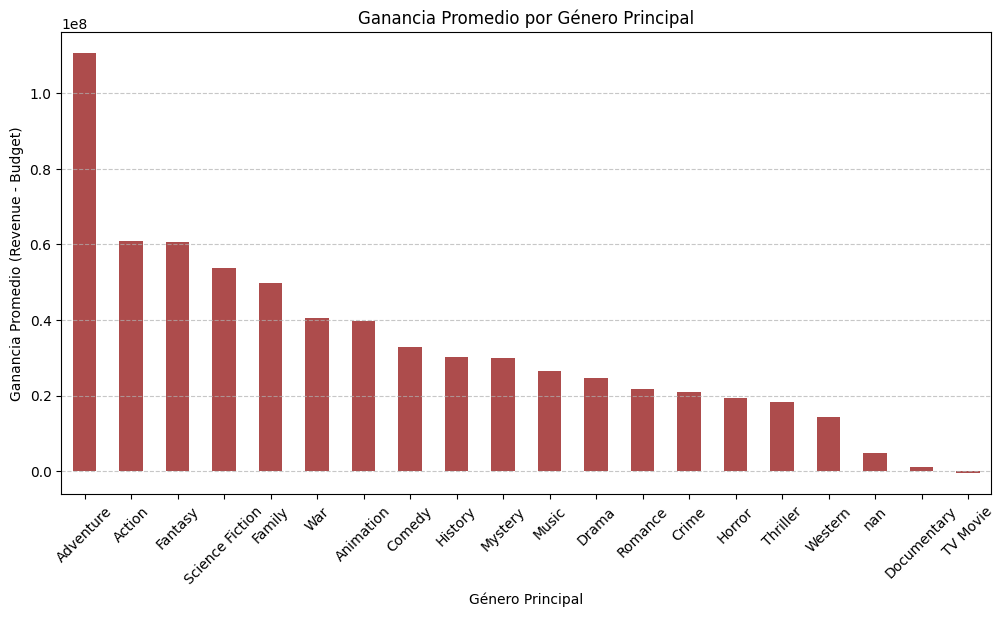

In [89]:
df['revenue'] = pd.to_numeric(df['revenue'], errors='coerce')
df['budget'] = pd.to_numeric(df['budget'], errors='coerce')
df['primaryGenre'] = df['genres'].astype(str).apply(lambda x: x.split('|')[0] if pd.notna(x) else 'Desconocido')
df['profit'] = df['revenue'] - df['budget']

genre_profits = df.groupby('primaryGenre')['profit'].mean().sort_values(ascending=False)

most_profitable_genre = genre_profits.idxmax()
highest_profit = genre_profits.max()

print(f"El género principal con mayores ganancias promedio es '{most_profitable_genre}' con una ganancia media de ${highest_profit:,.2f}.")

plt.figure(figsize=(12, 6))
genre_profits.plot(kind='bar', color='darkred', alpha=0.7)
plt.xlabel("Género Principal")
plt.ylabel("Ganancia Promedio (Revenue - Budget)")
plt.title("Ganancia Promedio por Género Principal")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## **11. ¿La cantidad de actores influye en los ingresos de las películas? ¿Se han hecho películas con más actores en los últimos años?**

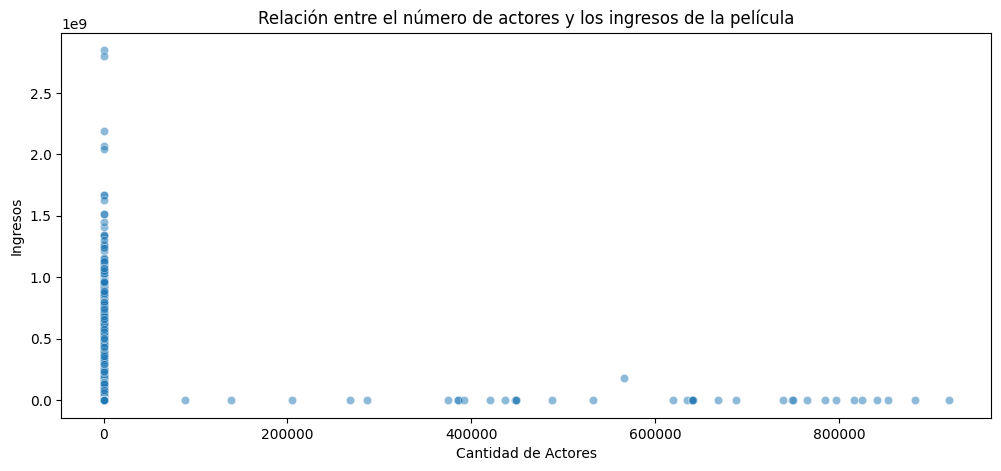

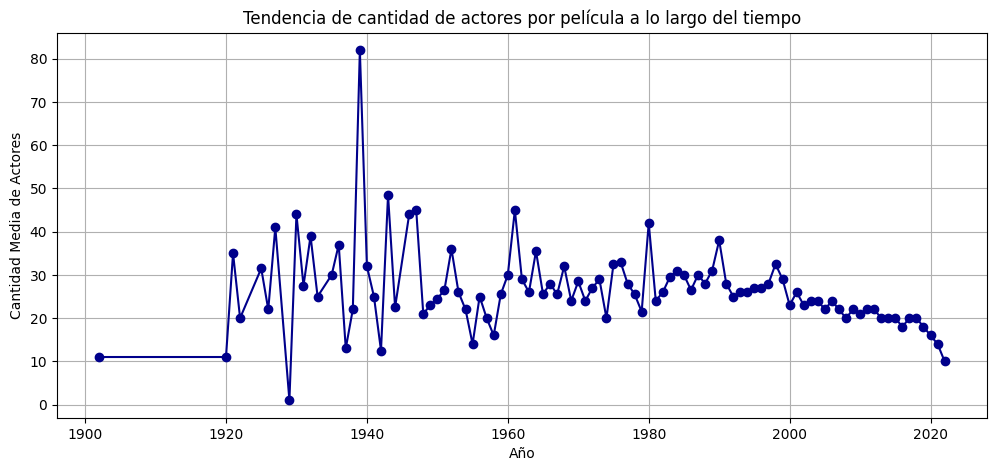

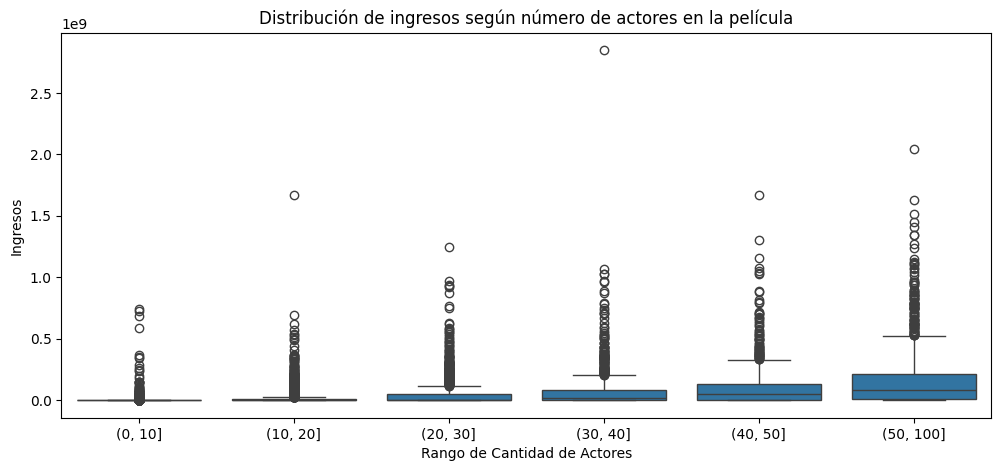

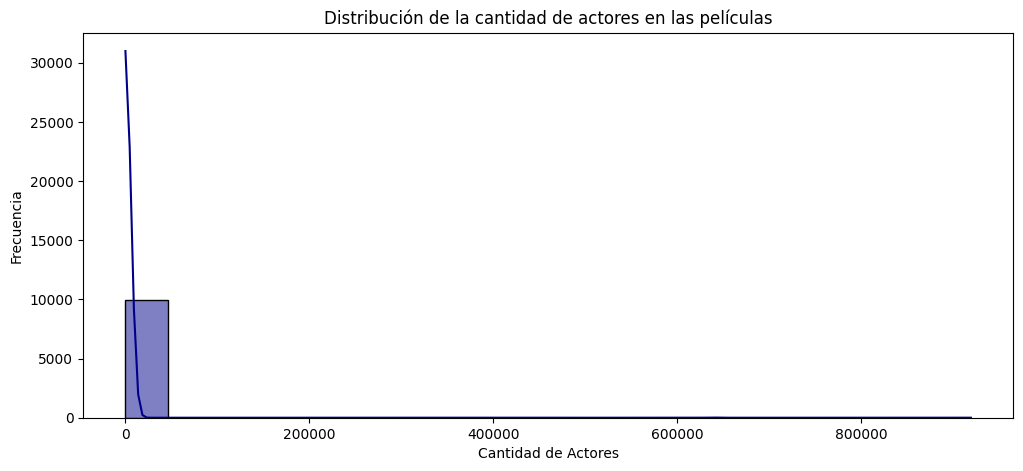

In [90]:
plt.figure(figsize=(12, 5))
sns.scatterplot(x=df['actorsAmount'], y=df['revenue'], alpha=0.5)
plt.xlabel("Cantidad de Actores")
plt.ylabel("Ingresos")
plt.title("Relación entre el número de actores y los ingresos de la película")
plt.show()

actors_per_year = df.groupby('releaseYear')['actorsAmount'].median()
plt.figure(figsize=(12, 5))
actors_per_year.plot(kind='line', marker='o', color='darkblue')
plt.xlabel("Año")
plt.ylabel("Cantidad Media de Actores")
plt.title("Tendencia de cantidad de actores por película a lo largo del tiempo")
plt.grid()
plt.show()

plt.figure(figsize=(12, 5))
sns.boxplot(x=pd.cut(df['actorsAmount'], bins=[0, 10, 20, 30, 40, 50, 100]), y=df['revenue'])
plt.xlabel("Rango de Cantidad de Actores")
plt.ylabel("Ingresos")
plt.title("Distribución de ingresos según número de actores en la película")
plt.show()

plt.figure(figsize=(12, 5))
sns.histplot(df['actorsAmount'].dropna(), bins=20, kde=True, color='darkblue')
plt.xlabel("Cantidad de Actores")
plt.ylabel("Frecuencia")
plt.title("Distribución de la cantidad de actores en las películas")
plt.show()

## **12. ¿Es posible que la cantidad de hombres y mujeres en el reparto influya en la popularidad y los ingresos de las películas?**

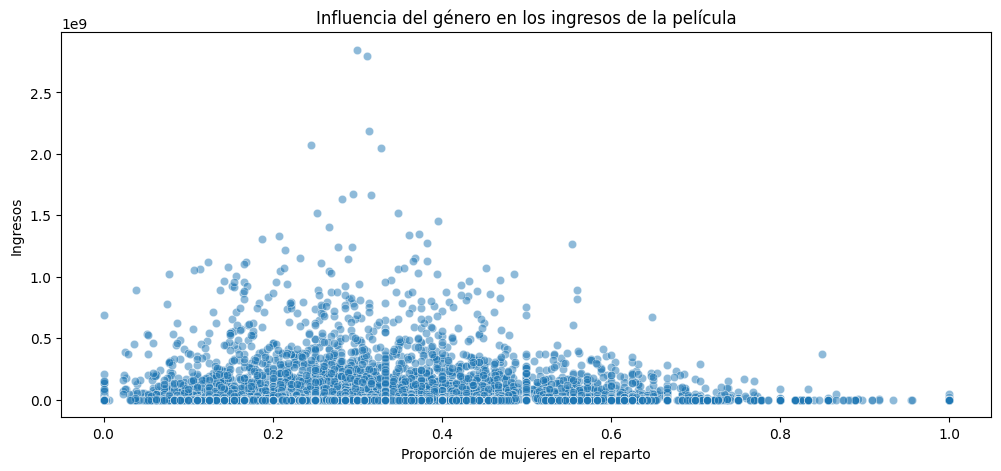

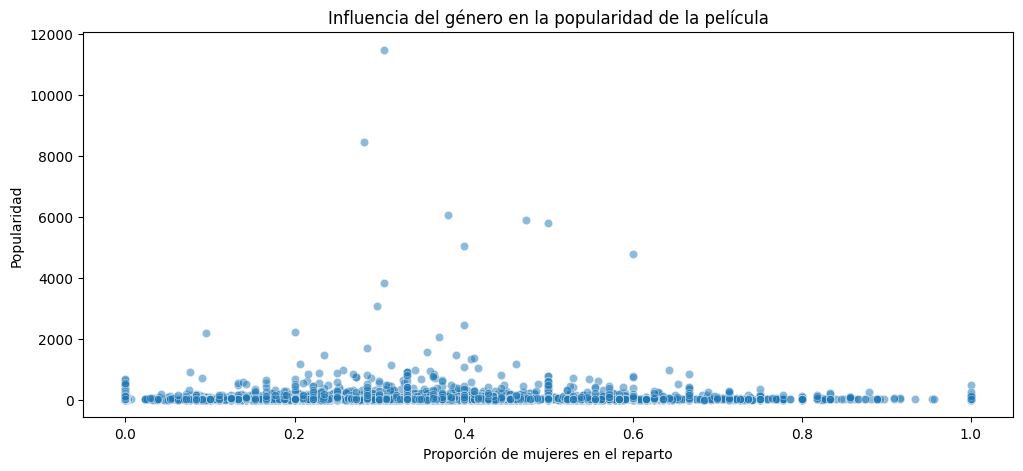

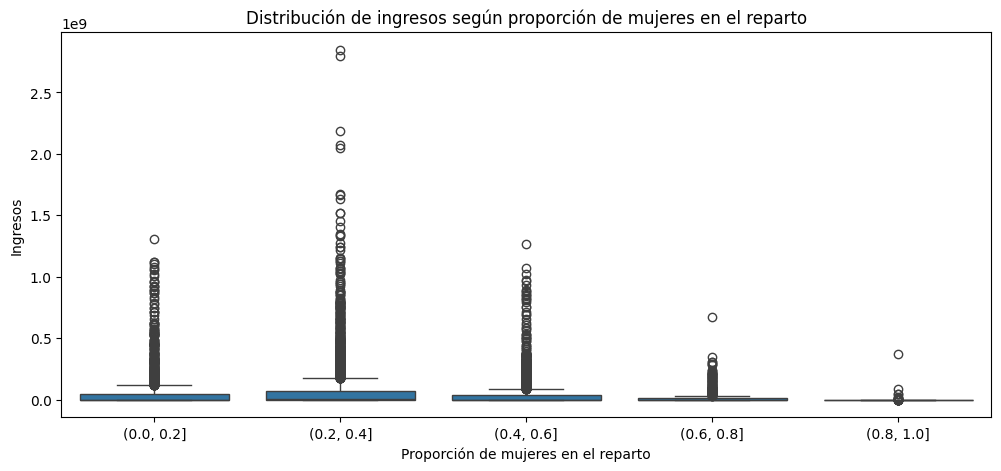

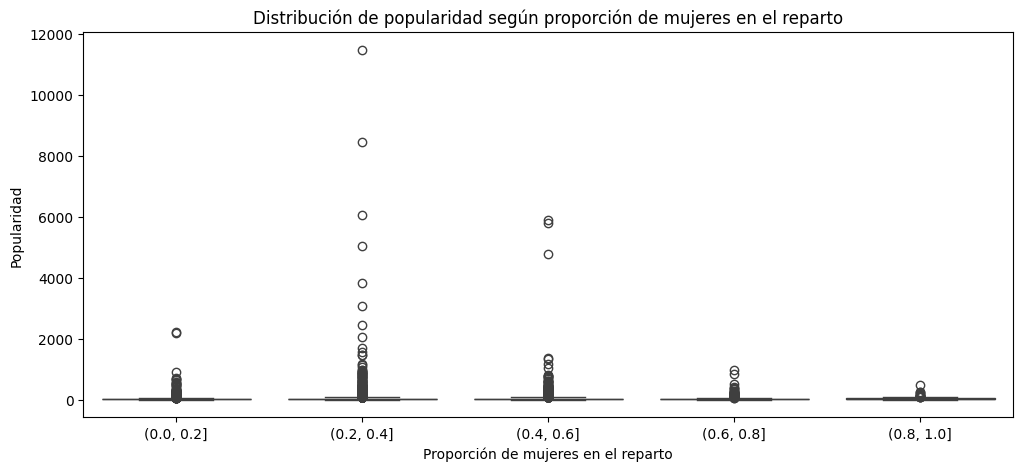

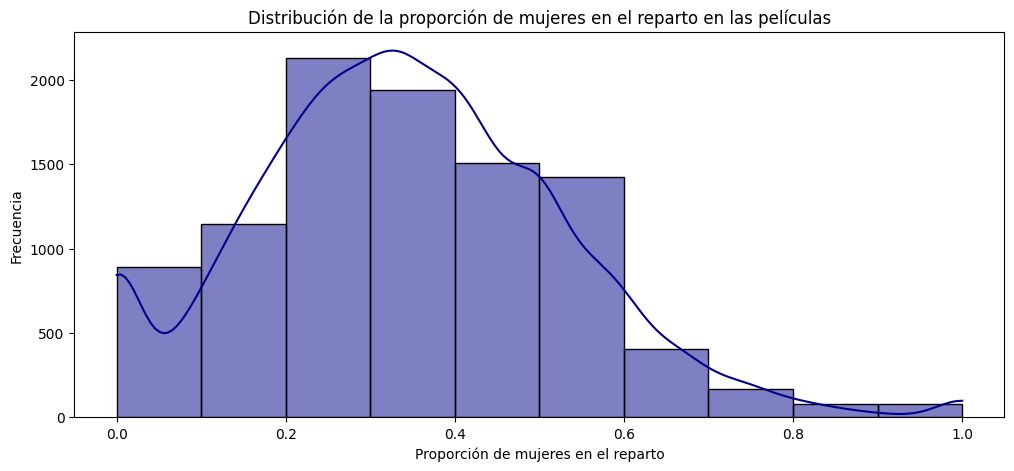

In [91]:
df['gender_ratio'] = df['castWomenAmount'] / (df['castWomenAmount'] + df['castMenAmount'])

plt.figure(figsize=(12, 5))
sns.scatterplot(x=df['gender_ratio'], y=df['revenue'], alpha=0.5)
plt.xlabel("Proporción de mujeres en el reparto")
plt.ylabel("Ingresos")
plt.title("Influencia del género en los ingresos de la película")
plt.show()

plt.figure(figsize=(12, 5))
sns.scatterplot(x=df['gender_ratio'], y=df['popularity'], alpha=0.5)
plt.xlabel("Proporción de mujeres en el reparto")
plt.ylabel("Popularidad")
plt.title("Influencia del género en la popularidad de la película")
plt.show()

plt.figure(figsize=(12, 5))
sns.boxplot(x=pd.cut(df['gender_ratio'], bins=[0, 0.2, 0.4, 0.6, 0.8, 1]), y=df['revenue'])
plt.xlabel("Proporción de mujeres en el reparto")
plt.ylabel("Ingresos")
plt.title("Distribución de ingresos según proporción de mujeres en el reparto")
plt.show()

plt.figure(figsize=(12, 5))
sns.boxplot(x=pd.cut(df['gender_ratio'], bins=[0, 0.2, 0.4, 0.6, 0.8, 1]), y=df['popularity'])
plt.xlabel("Proporción de mujeres en el reparto")
plt.ylabel("Popularidad")
plt.title("Distribución de popularidad según proporción de mujeres en el reparto")
plt.show()

plt.figure(figsize=(12, 5))
sns.histplot(df['gender_ratio'].dropna(), bins=10, kde=True, color='darkblue')
plt.xlabel("Proporción de mujeres en el reparto")
plt.ylabel("Frecuencia")
plt.title("Distribución de la proporción de mujeres en el reparto en las películas")
plt.show()

## **13. ¿Quiénes son los directores que hicieron las 20 películas mejor calificadas?**

In [92]:
top_rated_movies = df.sort_values(by='voteAvg', ascending=False).head(20)
directors_top_rated = top_rated_movies[['director', 'title', 'voteAvg']]
print("Directores de las 20 películas mejor calificadas:")
display(directors_top_rated)

Directores de las 20 películas mejor calificadas:


,director,title,voteAvg
9298,Laurent Bouzereau,Spirit of Vengeance: The Making of 'Ghost Rider',10.0
9733,Christin Baker,Christmas at the Ranch,10.0
9875,NaN,El Chavo Del Ocho: Lo Mejor De Don Ramon,10.0
9246,Rebecca Sugar,Steven Universe: The Movie: Behind the Curtain,10.0
9990,Miguel Angel Zavala,Los Vengadores Chiflados,10.0
8632,Thomas Coven,Hot Naked Sex & the City,10.0
9347,Kaku Arakawa,How Ponyo was Born ~Hayao Miyazaki's Thought P...,10.0
9084,Víctor Barba|Juan Olivares,Holidays,10.0
6750,NaN,Dragon Ball Kami BEST [Bonus DVD],9.8
6885,Dave Bullock|Troy Adomitis|Victor Cook,The Spectacular Spider-Man Attack of the Lizard,9.6


## **14. ¿Cómo se correlacionan los presupuestos con los ingresos? ¿Los altos presupuestos significan altos ingresos? Haga los gráficos que necesite, histograma, diagrama de dispersión.**

## **15. ¿Se asocian ciertos meses de lanzamiento con mejores ingresos?**

## **16. ¿En qué meses se han visto los lanzamientos con mejores ingresos? ¿Cuántas películas, en promedio, se han lanzado por mes?**

## **17. ¿Cómo se correlacionan las calificaciones con el éxito comercial?**

## **18. ¿Qué estrategias de marketing, como videos promocionales o páginas oficiales, generan mejores resultados?**

## **19. ¿La popularidad del elenco está directamente correlacionada con el éxito de taquilla?**

## **20. ¿Cuál es la relación entre el número de géneros de una película y sus ingresos?**

## **21. ¿Cuántas películas han sido producidas en más de un país y cómo afecta esto a sus ingresos?**

## **22. ¿Existe una relación entre la duración de una película y su calificación promedio?**

## **23. ¿Qué productoras han lanzado más películas y cuál es su éxito promedio en ingresos?**

## **24. ¿Las películas con página web tienen mejores ingresos y calificaciones?**

## **25. ¿Las películas de ciertos idiomas tienen una mayor rentabilidad en términos de ingresos respecto al presupuesto?**